# Laboratorio 1 - AlpesPlanck: Regresión lineal para predicción de temperatura máxima

## Importación de librerías

In [139]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn import set_config
set_config(display="diagram")

pd.set_option('display.max_colwidth', None)

## Carga de los datos

In [140]:
datos_laboratorio = pd.read_csv('./data/Datos Lab 1.csv')
data = datos_laboratorio.copy()

diccionario = pd.read_excel('./data/Diccionario de datos.xlsx')
data.shape

(2576, 27)

# 1. Exploración de los datos

Clasificamos primero las variables según su naturaleza estadística, y luego
exploramos el dataset con `pandas` para identificar problemas de calidad.

In [141]:
cuantitativas_continuas = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'temp_max_manana',
]

cuantitativas_discretas = [
    'registros_del_dia',
    'anio',
    'dia_del_anio'
]

cualitativas_nominales = [
    'estacion_anio',
    'mes',
    'sector_viento',
    'fecha'
]

cualitativas_ordinales = []

### 1.1 Exploración general

A continuación se ejecutan las  exploraciones iniciales sobre el
dataset, para identificar el porcentaje de datos nulos por variable,
ver consistencia de variables categóricas, ver datos repetidos y la validez de dstos.

In [142]:
print(data.describe(include='object'))

             fecha estacion_anio   mes sector_viento
count         2504          2488  2488          2505
unique        2486            28    61            33
top     2010-08-14     primavera   May            SO
freq             2           517   127           695


**Revisar porcentaje de nulidad por variable**

In [143]:
print(((data.isnull().sum() / data.shape[0])).sort_values(ascending=False))

temp_max_manana      0.036879
viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
presion_desv         0.031056
humedad_min          0.031056
viento_norte         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
humedad_media        0.028727
presion_min          0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
dtype: float64


**Revisar filas duplicadas**

In [144]:
print(int(data.duplicated(keep=False).sum()))
duplicados = datos_laboratorio[datos_laboratorio.duplicated()]
print(duplicados)

8
           fecha  presion_media  presion_min  presion_max  presion_desv  \
2556  2013-04-20      1000.4455       998.46      1002.49        1.1632   
2559  2012-11-13      1005.3724      1002.77      1006.81        1.0690   
2563  2009-01-22      9784.1150       971.48       983.54        3.9853   
2565  2013-02-08       984.6369       983.06       987.49        1.3454   

      humedad_media  humedad_min  humedad_max  humedad_desv  viento_media  \
2556      60.748100        45.71         82.0       10.9518      17.65908   
2559      88.175500        58.28         99.1       12.6853       4.07916   
2563      86.731100        69.11         97.6        9.7926      10.09692   
2565       0.886056         0.76         96.8        4.6160           NaN   

      ...  viento_norte  viento_este  direccion_viento  registros_del_dia  \
2556  ...        4.1573       2.5121           31.1426              144.0   
2559  ...       -0.9230      -0.2193          193.3681              144.0   
2563 

**Revisar consistencia de variable sector_viento**

In [145]:
print(data['sector_viento'].value_counts())

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
ne            19
South         19
NORTHEAST     17
Sur           16
Noreste       12
SOUTH          8
o              8
no             6
NORTH          6
West           5
WEST           5
EAST           4
North          4
East           4
SOUTHEAST      3
Sureste        3
Oeste          3
Noroeste       3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64


**Revisar consistencia de variable mes**

In [146]:
print(data['mes'].value_counts())

mes
May           127
August        125
July          123
January       120
March         118
             ... 
septiembre     16
april          16
junio          16
OCTOBER        13
Jan            13
Name: count, Length: 61, dtype: int64


**Revisar consistencia de variable estacion_anio**

In [147]:
print(data['estacion_anio'].value_counts())

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Invierno                  9
Verano                    9
invierno                  9
INVIERNO                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64


**Revisar validez de variables con rangos, usando mínimos y máximos**

In [148]:
print(data.describe())

       presion_media  presion_min  presion_max  presion_desv  humedad_media  \
count    2501.000000  2502.000000  2512.000000   2496.000000    2502.000000   
mean     1010.494271   986.684409   991.704244      1.752041      52.413586   
std       435.334494     8.927138     7.726906      1.215931      35.975384   
min       948.996000   913.600000   951.940000      0.226900       0.004663   
25%       984.287800   981.371333   987.070000      0.899050       0.869060   
50%       989.452800   987.070000   991.935000      1.444550      68.558100   
75%       994.469000   992.567500   996.782500      2.254800      80.562600   
max      9939.918000  1012.320198  1013.940000     12.397500     100.000000   

       humedad_min  humedad_max  humedad_desv  viento_media   viento_min  ...  \
count  2496.000000  2490.000000   2515.000000   2490.000000  2485.000000  ...   
mean     45.094067    90.236582     10.606821      3.814103     1.417799  ...   
std      30.196163    10.647237      5.481338

### 1.2 Evidencia de problemas de **validez** (rangos incorrectos)

Un valor es inválido cuando, aunque esté presente (no es nulo), **no tiene sentido
físico** para lo que representa: una humedad relativa no puede superar el 100%,
una presión atmosférica no puede ser 10 veces el máximo histórico registrado en la
Tierra, una desviación estándar no puede ser negativa, etc. A continuación se
contrasta el mínimo y el máximo real de cada variable contra el rango físicamente
válido (según el diccionario de datos y la naturaleza del fenómeno).

In [149]:
rangos_validos = {
    'presion_media': (900, 1085),
    'presion_min': (900, 1085),
    'presion_max': (900, 1085),
    'presion_desv': (0, 50),
    'humedad_media': (0, 100),
    'humedad_min': (0, 100),
    'humedad_max': (0, 100),
    'humedad_desv': (0, 100),
    'viento_media': (0, 60),
    'viento_min': (0, 60),
    'viento_max': (0, 60),
    'viento_desv': (0, 60),
    'rafaga_media': (0, 100),
    'rafaga_min': (0, 100),
    'rafaga_max': (0, 100),
    'rafaga_desv': (0, 100),
    'viento_norte': (-60, 60),
    'viento_este': (-60, 60),
    'direccion_viento': (0, 360),     # dic: "de 0 a 360 grados"
    'registros_del_dia': (0, 144),    # dic: "un dia completo tiene 144"
    'anio': (2003, 2015),             # la estacion mide desde 2003
    'dia_del_anio': (1, 366),         # dic: "de 1 a 366"
}

print(f'{"variable":18s} {"min_real":>12s} {"max_real":>12s}  dentro_rango?')
for var, (lo, hi) in rangos_validos.items():
    mn, mx = data[var].min(), data[var].max()
    dentro = (mn >= lo) and (mx <= hi)
    marca = '' if dentro else '  <-- FUERA DE RANGO (problema de validez)'
    print(f'{var:18s} {mn:12.3f} {mx:12.3f}  {str(dentro):>12s}{marca}')

variable               min_real     max_real  dentro_rango?
presion_media           948.996     9939.918         False  <-- FUERA DE RANGO (problema de validez)
presion_min             913.600     1012.320          True
presion_max             951.940     1013.940          True
presion_desv              0.227       12.398          True
humedad_media             0.005      100.000          True
humedad_min               0.238      103.311         False  <-- FUERA DE RANGO (problema de validez)
humedad_max              27.020      100.000          True
humedad_desv              0.000       26.342          True
viento_media              0.000       24.754          True
viento_min                0.000       45.185          True
viento_max                0.000       45.108          True
viento_desv               0.000     3319.030         False  <-- FUERA DE RANGO (problema de validez)
rafaga_media          -1386.273       11.465         False  <-- FUERA DE RANGO (problema de validez)
rafag

**Hallazgo:** `presion_media`, `humedad_min`, `viento_desv`, `rafaga_media`,
`rafaga_min`, `rafaga_desv`, `viento_norte` y `registros_del_dia` tienen valores
que violan su rango físicamente válido (por ejemplo, `rafaga_min` llega a **-9999**,
un valor típico de sensor/registro fallido; `presion_media` llega a
**~9939 mbar**, unas 10 veces la presión atmosférica máxima físicamente posible).
Esto **no** es un problema de completitud (los datos están presentes, no son
nulos): es un problema de **validez** — el dato existe, pero es incorrecto o no
tiene sentido para la variable que representa.

### 1.3 Evidencia de problemas de **consistencia** (formato de categóricas)

Ya se observó en el punto 1.1 (`value_counts`) que `estacion_anio`, `mes` y
`sector_viento` tienen la misma información representada de formas distintas:
mayúsculas/minúsculas, texto en inglés, tildes, abreviaturas y errores de
digitación. Esto es un problema de **consistencia**: la variable debería tener un
único formato válido (el que define el diccionario de datos), y en cambio la
misma categoría aparece bajo múltiples representaciones.

In [150]:
for col in ['estacion_anio', 'mes', 'sector_viento']:
    print(f'--- {col}: {data[col].nunique()} valores unicos encontrados ---')
    print(sorted(data[col].dropna().unique().tolist()))
    print()

--- estacion_anio: 28 valores unicos encontrados ---
['East', 'Estacion_Desconocida', 'INVIERNO', 'Inverano', 'Invierno', 'OTONO', 'Otoño', 'PRIMAVERA', 'Primavera', 'VERANO', 'VERANO_INVIERNO', 'Verano', 'autumn', 'berano', 'fall', 'invernio', 'invierno', 'invierno ', 'otono', 'otoño ', 'primav', 'primavera', 'primaveraa', 'spring', 'summer', 'verano', 'verno', 'winter']

--- mes: 61 valores unicos encontrados ---
['APRIL', 'AUGUST', 'Apr', 'April', 'Aug', 'August', 'DECEMBER', 'Dec', 'December', 'Enero', 'FEBRUARY', 'Feb', 'February', 'JANUARY', 'JULY', 'JUNE', 'Jan', 'January', 'Jul', 'July', 'Jun', 'June', 'MARCH', 'MAY', 'Mar', 'March', 'May', 'NOVEMBER', 'Nov', 'November', 'OCTOBER', 'Oct', 'October', 'SEPTEMBER', 'Sep', 'Sept', 'September', 'abril', 'agosto', 'april', 'august', 'december', 'diciembre', 'enero', 'febrero', 'february', 'january', 'julio', 'july', 'june', 'junio', 'march', 'marzo', 'may', 'mayo', 'november', 'noviembre', 'october', 'octubre', 'september', 'septiemb

**Hallazgo:** por ejemplo `estacion_anio` tiene *primavera*, *Primavera*,
*PRIMAVERA*, *primav*, *primaveraa* y *spring* —seis representaciones de la
misma categoría—, además de valores inválidos como `East` o
`Estacion_Desconocida` que no corresponden a ninguna estación del año.

### 1.4 Evidencia de problemas de **completitud** (valores nulos)

Ya se observó en el punto 1.1 el porcentaje de nulos por columna. La variable
objetivo `temp_max_manana` también tiene nulos, así como varias variables
predictoras. Este es un problema de **completitud**: el dato simplemente no fue
registrado.

### 1.5 Resumen de hallazgos y dimensiones de calidad de datos

| Dimensión | Problema encontrado | Variables afectadas |
|---|---|---|
| **Validez** | Valores presentes pero fuera del rango físicamente posible (incl. un valor centinela `-9999`) | `presion_media`, `humedad_min`, `viento_desv`, `rafaga_media`, `rafaga_min`, `rafaga_desv`, `viento_norte`, `registros_del_dia` |
| **Consistencia** | La misma categoría representada en múltiples formatos (mayúsculas, inglés, tildes, typos) | `estacion_anio`, `mes`, `sector_viento` |
| **Completitud** | Valores nulos | Prácticamente todas las columnas, incluida la variable objetivo `temp_max_manana` |
| **unicidad** | Valores duplicados | 4 filas duplicadas |

En la sección 2 (Preparación de datos) se define, para cada dimensión, la
estrategia de corrección y su justificación.

# 2. Preparación de datos

Cada corrección se diseña según la dimensión de calidad de datos a la que
responde:

- **Validez** → los valores fuera de rango se corrigen según el tipo de error
  específico de cada variable (recorte al límite, valor absoluto, o marcarlo como
  error para reemplazarlo más adelante).
- **Consistencia** → las categóricas se normalizan (sin tildes, en minúsculas) y
  se mapean al formato exacto que exige el diccionario de datos.
- **Completitud** → los valores nulos se imputan: en variables **categóricas**
  con la **moda**; en variables **cuantitativas**, con la **media** si la
  variable está dentro de su rango normal, o con la **mediana** si tiene valores
  fuera de rango (la mediana es más robusta ante esa contaminación).
- **Unicidad** → Las filas dupicadas se eiminan dejando una sola versión

> **Nota metodológica (fuga de datos):** estas funciones se **definen** aquí,
> pero no se aplican todavía sobre todo el dataset. La normalización de
> categóricas y la corrección de rangos no dependen de ningún estadístico
> calculado sobre los datos (son reglas fijas), así que son seguras de aplicar
> en cualquier momento; pero la **imputación de nulos sí es un estadístico**
> (media/mediana/moda), por lo que debe calcularse **únicamente con el
> conjunto de entrenamiento**. Por eso la imputación se implementa con
> `SimpleImputer`.

### 2.1 Corrección de consistencia (formato de categóricas)

In [151]:
def quitar_tildes(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

def normalizar_texto(valor):
    return quitar_tildes(str(valor).strip().lower())

mapa_estacion_anio = {
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primav': 'primavera', 'primaveraa': 'primavera', 'spring': 'primavera',
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'otono': 'otoño', 'fall': 'otoño', 'autumn': 'otoño',
}

mapa_mes = {
    'january': 'enero', 'jan': 'enero', 'enero': 'enero',
    'february': 'febrero', 'feb': 'febrero', 'febrero': 'febrero',
    'march': 'marzo', 'mar': 'marzo', 'marzo': 'marzo',
    'april': 'abril', 'apr': 'abril', 'abril': 'abril',
    'may': 'mayo', 'mayo': 'mayo',
    'june': 'junio', 'jun': 'junio', 'junio': 'junio',
    'july': 'julio', 'jul': 'julio', 'julio': 'julio',
    'august': 'agosto', 'aug': 'agosto', 'agosto': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre', 'septiembre': 'septiembre',
    'october': 'octubre', 'oct': 'octubre', 'octubre': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre', 'noviembre': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre', 'diciembre': 'diciembre',
}

mapa_sector_viento = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'e': 'E', 'east': 'E', 'este': 'E',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    's': 'S', 'south': 'S', 'sur': 'S',
    'so': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
    'o': 'O', 'west': 'O', 'oeste': 'O',
    'no': 'NO', 'northwest': 'NO', 'noroeste': 'NO',
}

def normalizar_categoricas(df):
    # Consistencia: cada categoria se lleva al unico formato valido del diccionario.
    df = df.copy()
    df['estacion_anio'] = df['estacion_anio'].apply(
        lambda x: mapa_estacion_anio.get(normalizar_texto(x)) if pd.notna(x) else x)
    df['mes'] = df['mes'].apply(
        lambda x: mapa_mes.get(normalizar_texto(x)) if pd.notna(x) else x)
    df['sector_viento'] = df['sector_viento'].apply(
        lambda x: mapa_sector_viento.get(normalizar_texto(x)) if pd.notna(x) else x)
    return df

corrector_categoricas = FunctionTransformer(normalizar_categoricas)

### 2.2 Corrección de validez (valores fuera de rango)

La estrategia se elige según el patrón de error específico de cada variable
(ver el diagnóstico detallado hecho previamente sobre este mismo dataset):

| Variable | Patrón encontrado | Estrategia |
|---|---|---|
| `presion_media` | Valores ~10x el real, sin patrón limpio de digito repetido | Error -> se marca NaN (se completa por completitud en el pipeline) |
| `humedad_min` | Apenas supera el 100% | Recorte al límite (`clip`) |
| `viento_desv` | Un extremo aislado (~10x el resto) + valores moderadamente fuera de rango | Extremo -> NaN; resto -> `clip` |
| `rafaga_media` | Un valor extremo negativo | Error -> NaN |
| `rafaga_min` | Valor centinela `-9999` | Error -> NaN |
| `rafaga_desv` | Muchos valores negativos (una desviación estándar nunca es negativa) | Signo -> `abs()`, luego `clip` |
| `viento_norte` | Un valor extremo aislado | Error -> NaN |
| `registros_del_dia` | Supera el máximo físico de 144 registros/día | Recorte al límite (`clip`) |

In [152]:
def corregir_rangos_numericos(df):
    df = df.copy()

    # presion_media: atipico = error de validez -> NaN
    lo, hi = rangos_validos['presion_media']
    fuera = (df['presion_media'] < lo) | (df['presion_media'] > hi)
    df.loc[fuera, 'presion_media'] = np.nan

    # humedad_min: fuera de rango leve -> clip
    lo, hi = rangos_validos['humedad_min']
    df['humedad_min'] = df['humedad_min'].clip(lower=lo, upper=hi)

    # viento_desv: extremo aislado (>1000) = error -> NaN; resto -> clip
    df.loc[df['viento_desv'] > 1000, 'viento_desv'] = np.nan
    lo, hi = rangos_validos['viento_desv']
    df['viento_desv'] = df['viento_desv'].clip(lower=lo, upper=hi)

    # rafaga_media: atipico = error -> NaN
    lo, hi = rangos_validos['rafaga_media']
    fuera = (df['rafaga_media'] < lo) | (df['rafaga_media'] > hi)
    df.loc[fuera, 'rafaga_media'] = np.nan

    # rafaga_min: -9999 (centinela) = error -> NaN
    lo, hi = rangos_validos['rafaga_min']
    fuera = (df['rafaga_min'] < lo) | (df['rafaga_min'] > hi)
    df.loc[fuera, 'rafaga_min'] = np.nan

    # rafaga_desv: negativo deberia ser positivo -> abs(), luego clip
    df['rafaga_desv'] = df['rafaga_desv'].abs()
    lo, hi = rangos_validos['rafaga_desv']
    df['rafaga_desv'] = df['rafaga_desv'].clip(lower=lo, upper=hi)

    # viento_norte: atipico = error -> NaN
    lo, hi = rangos_validos['viento_norte']
    fuera = (df['viento_norte'] < lo) | (df['viento_norte'] > hi)
    df.loc[fuera, 'viento_norte'] = np.nan

    # registros_del_dia: fuera de rango -> clip
    lo, hi = rangos_validos['registros_del_dia']
    df['registros_del_dia'] = df['registros_del_dia'].clip(lower=lo, upper=hi)

    return df

corrector_rangos = FunctionTransformer(corregir_rangos_numericos)

### 2.3 Corrección de completitud (imputación de nulos)

**Regla:** en las variables cuantitativas, se imputa con la **media** si la
variable se encuentra dentro de su rango normal, y con la **mediana** si tiene
valores fuera de rango (dato contaminado por atípicos). Como en el paso 2.2 ya se
corrigieron todos los valores fuera de rango, **todas** las variables numéricas
quedan dentro de su rango válido — por lo tanto, todas califican para
imputación con **media**. En las variables categóricas nominales/ordinales, los
nulos se imputan con la **moda**.

Esta imputación se implementa con `SimpleImputer` dentro del `Pipeline` de
modelado (sección 3), ajustado **solo con el conjunto de entrenamiento**, para
no incurrir en fuga de datos.

### 2.4 Corrección de Unicidad 

Se eliminan las filas duplicadas del set de datos, antes de separar los datos de entrenamiento y crear el pipeline.

In [153]:
data = data.drop_duplicates().reset_index(drop=True)
print(int(data.duplicated(keep=False).sum()))

0


### 2.5 Eliminación de columnas no predictoras y del target nulo

`fecha` es un identificador (ya está descompuesta en `anio`, `mes`,
`dia_del_anio`, `estacion_anio`), así que se elimina como variable predictora.
La variable objetivo `temp_max_manana` **no se imputa** (imputar una etiqueta
sería inventar el dato que se quiere predecir); en su lugar se eliminan las filas
donde es nula, antes de dividir en train/test. Esta es una operación que no usa
ningún estadístico calculado sobre los datos, por lo que es segura de aplicar
antes del split.

In [154]:
cols_to_drop = ['fecha']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors='ignore')

dropper = FunctionTransformer(drop_columns)

In [155]:
n_antes = data.shape[0]
data = data.dropna(subset=['temp_max_manana']).reset_index(drop=True)
print(f'Filas eliminadas por temp_max_manana nula: {n_antes - data.shape[0]}')
print(f'Filas restantes: {data.shape[0]}')

Filas eliminadas por temp_max_manana nula: 95
Filas restantes: 2477


### 2.6 Partición train / test

Se usa la semilla y proporción indicadas en las consideraciones del laboratorio: `random_state=42`, `test_size=0.25`.

In [156]:
target = 'temp_max_manana'
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((1857, 26), (620, 26))

# 3. Construcción de dos modelos de regresión lineal

Se construyen dos modelos con estrategias de preparación diferentes y
justificadas, ambos usando las correcciones de validez y consistencia definidas
en la sección 2 dentro de sus respectivos pipelines.

## 3.1 Modelo 1 — Preparación estándar (todas las variables, imputación con media)

**Estrategia:** se usan **todas** las variables disponibles tras la limpieza. Las
numéricas se imputan con la **media** (justificado en 2.3: tras corregir los
rangos, todas las variables quedan dentro de límites válidos) y se **escalan**
con `StandardScaler`. Las categóricas se imputan con la **moda** y se codifican
con One-Hot Encoding. Es la estrategia conservadora: usa toda la información
disponible sin asumir qué variables son redundantes.

In [157]:
numeric_features_m1 = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio', 'dia_del_anio',
]

categorical_features_m1 = ['estacion_anio', 'mes', 'sector_viento']

numeric_transformer_m1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])

categorical_transformer_m1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
])

preprocessor_m1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_m1, numeric_features_m1),
    ('cat', categorical_transformer_m1, categorical_features_m1),
])

pipeline_m1 = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_m1),
    ('modelo', LinearRegression()),
])

pipeline_m1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_categoricas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x1104f1580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

In [158]:
pipeline_m1.fit(X_train, y_train)

y_train_pred_m1 = pipeline_m1.predict(X_train)
y_test_pred_m1 = pipeline_m1.predict(X_test)

rmse_train_m1 = np.sqrt(mean_squared_error(y_train, y_train_pred_m1))
mae_train_m1 = mean_absolute_error(y_train, y_train_pred_m1)
r2_train_m1 = r2_score(y_train, y_train_pred_m1)

rmse_test_m1 = np.sqrt(mean_squared_error(y_test, y_test_pred_m1))
mae_test_m1 = mean_absolute_error(y_test, y_test_pred_m1)
r2_test_m1 = r2_score(y_test, y_test_pred_m1)

print('Modelo 1 (todas las variables, media + escalado)')
print(f'  Train -> RMSE: {rmse_train_m1:.4f} | MAE: {mae_train_m1:.4f} | R2: {r2_train_m1:.4f}')
print(f'  Test  -> RMSE: {rmse_test_m1:.4f} | MAE: {mae_test_m1:.4f} | R2: {r2_test_m1:.4f}')

Modelo 1 (todas las variables, media + escalado)
  Train -> RMSE: 6.7329 | MAE: 5.1464 | R2: 0.4661
  Test  -> RMSE: 6.7805 | MAE: 5.2647 | R2: 0.4631


## 3.2 Modelo 2 — Preparación con reducción de variables redundantes (mitiga multicolinealidad)

**Estrategia:** dentro de cada grupo de medición (presión, humedad, viento,
ráfaga) las variables `min`, `max` y `desv` están, por construcción, muy
correlacionadas con su `media` del mismo día. Mantenerlas todas genera
**multicolinealidad**, que inestabiliza los coeficientes del modelo lineal. Por
eso, en este segundo modelo:

- Se conserva solo la variable `_media` de cada grupo.
- Se descarta `direccion_viento` (variable angular en 0°/360°,
  redundante con las variables de `viento_norte`/`viento_este`).
- Las numéricas se imputan con la **mediana** (estrategia alternativa, más
  robusta) y **no se escalan** (en una regresión lineal sin regularización el
  escalado no cambia las predicciones, solo la magnitud de los coeficientes).
- Las categóricas se preparan igual que en el Modelo 1.

In [159]:
numeric_features_m2 = [
    'presion_media',
    'humedad_media',
    'viento_media',
    'rafaga_media',
    'viento_norte', 'viento_este',
    'registros_del_dia', 'anio', 'dia_del_anio',
]

categorical_features_m2 = ['estacion_anio', 'mes', 'sector_viento']

numeric_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer_m2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary')),
])

preprocessor_m2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_m2, numeric_features_m2),
    ('cat', categorical_transformer_m2, categorical_features_m2),
])

pipeline_m2 = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('preprocesamiento', preprocessor_m2),
    ('modelo', LinearRegression()),
])

pipeline_m2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_categoricas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x1104f1580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

In [160]:
pipeline_m2.fit(X_train, y_train)

y_train_pred_m2 = pipeline_m2.predict(X_train)
y_test_pred_m2 = pipeline_m2.predict(X_test)

rmse_train_m2 = np.sqrt(mean_squared_error(y_train, y_train_pred_m2))
mae_train_m2 = mean_absolute_error(y_train, y_train_pred_m2)
r2_train_m2 = r2_score(y_train, y_train_pred_m2)

rmse_test_m2 = np.sqrt(mean_squared_error(y_test, y_test_pred_m2))
mae_test_m2 = mean_absolute_error(y_test, y_test_pred_m2)
r2_test_m2 = r2_score(y_test, y_test_pred_m2)

print('Modelo 2 (variables reducidas, mediana, sin escalado)')
print(f'  Train -> RMSE: {rmse_train_m2:.4f} | MAE: {mae_train_m2:.4f} | R2: {r2_train_m2:.4f}')
print(f'  Test  -> RMSE: {rmse_test_m2:.4f} | MAE: {mae_test_m2:.4f} | R2: {r2_test_m2:.4f}')

Modelo 2 (variables reducidas, mediana, sin escalado)
  Train -> RMSE: 8.0820 | MAE: 6.2794 | R2: 0.2307
  Test  -> RMSE: 8.0624 | MAE: 6.3832 | R2: 0.2410


# Modelo 3: Interacciones y no linealidades
Tener en cuenta las interacciones entre categorias y variables numericas al igual que relaciones no lineales entre la variable explicativa y la variable temperatura.

Podemos empezar por considerar que hay relaciones las cuales no son lineales, para esto es necesario visualizar cada relacion

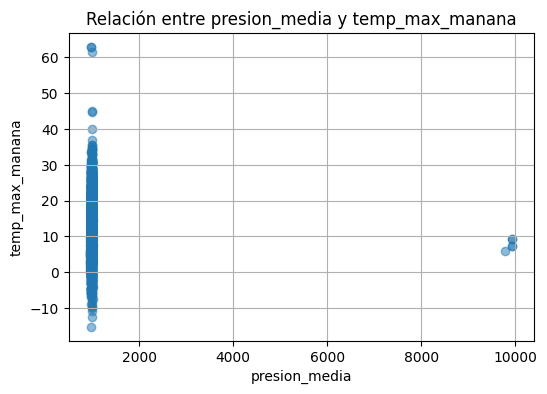

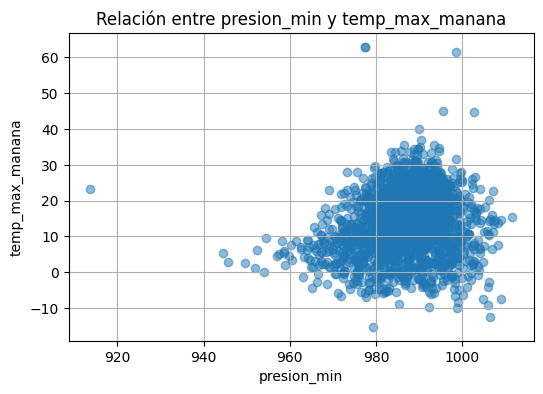

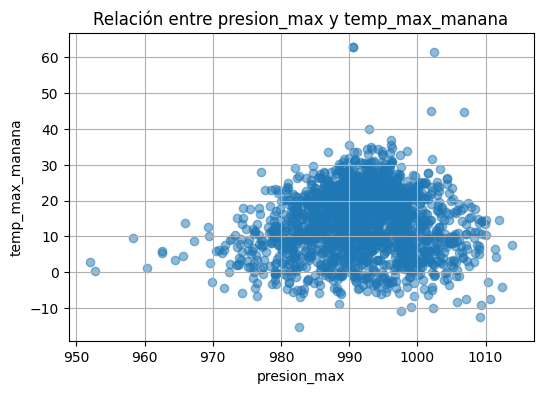

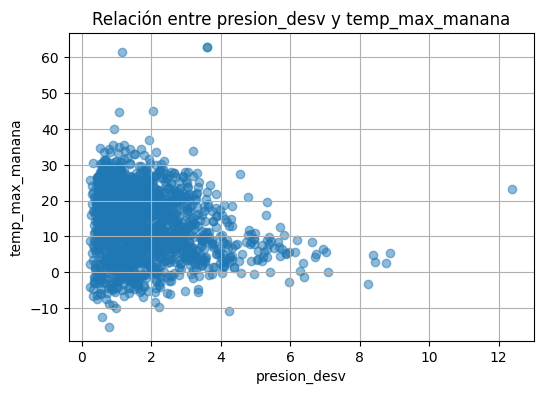

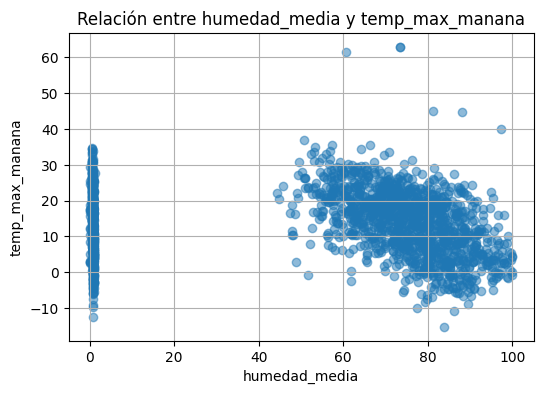

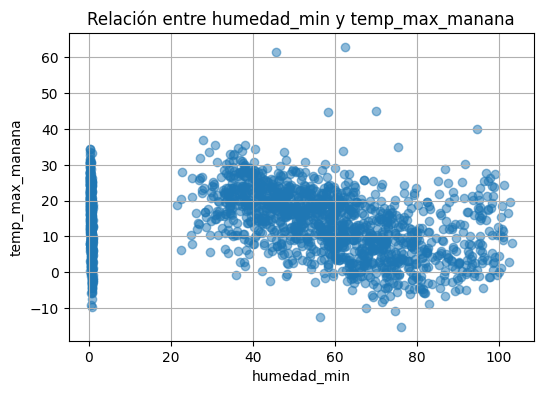

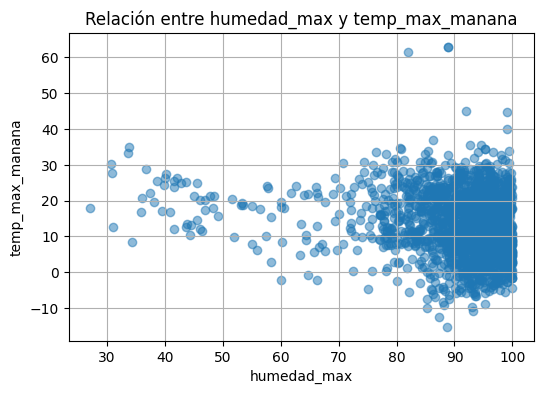

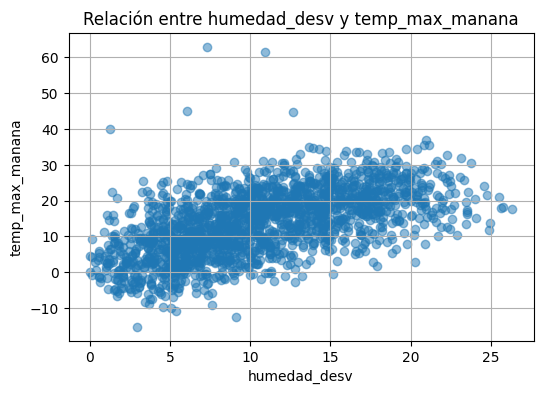

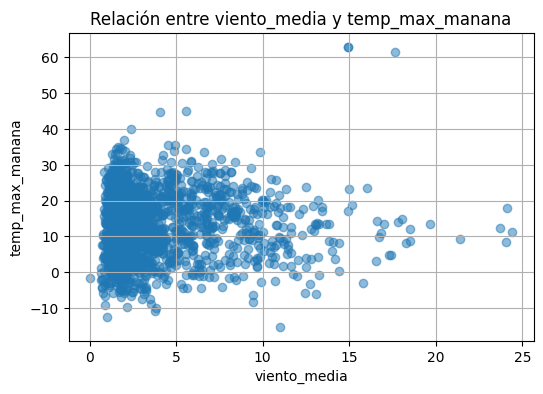

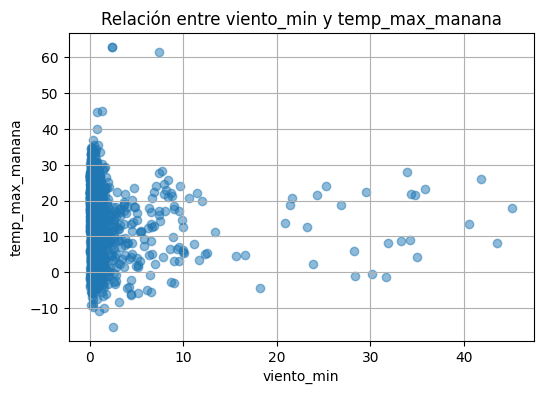

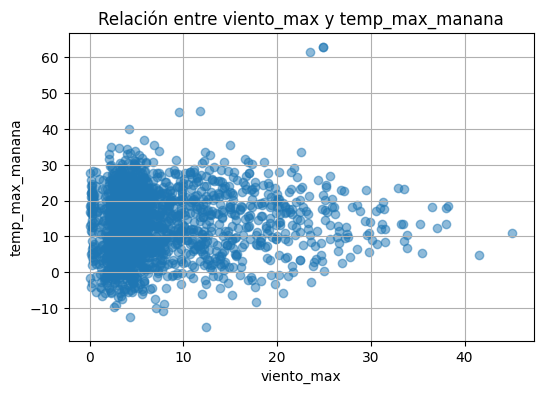

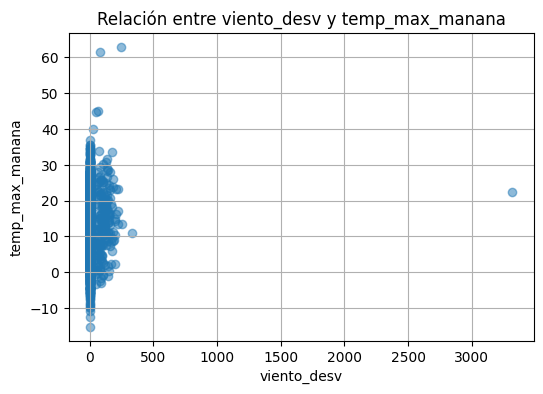

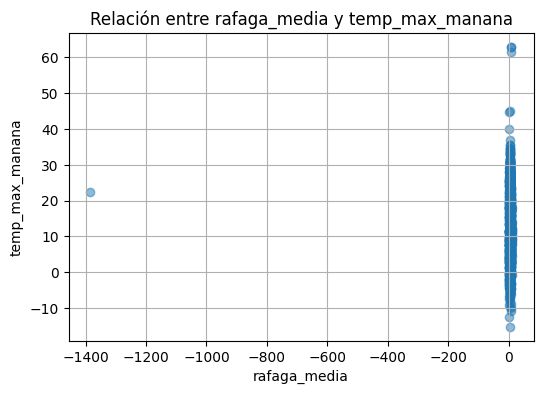

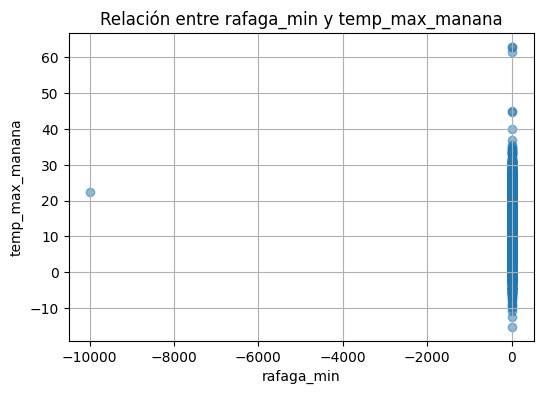

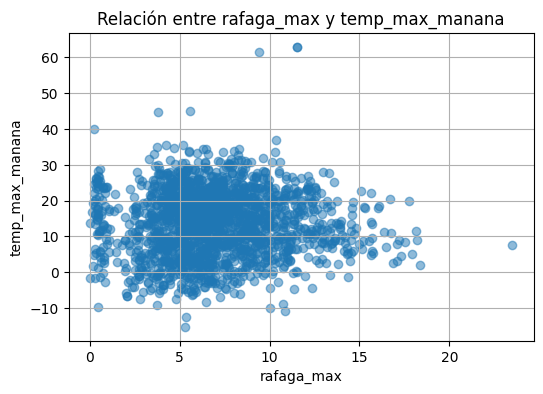

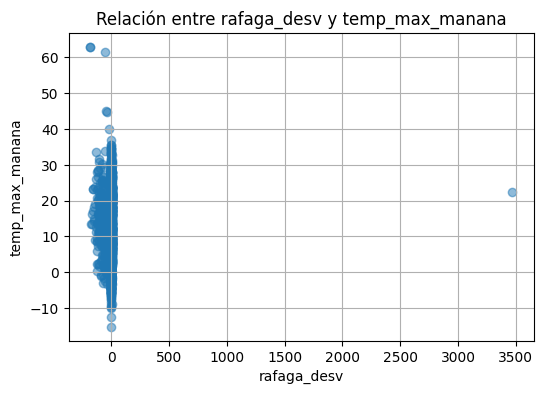

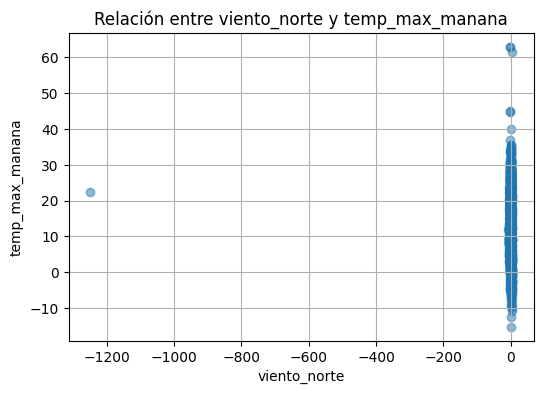

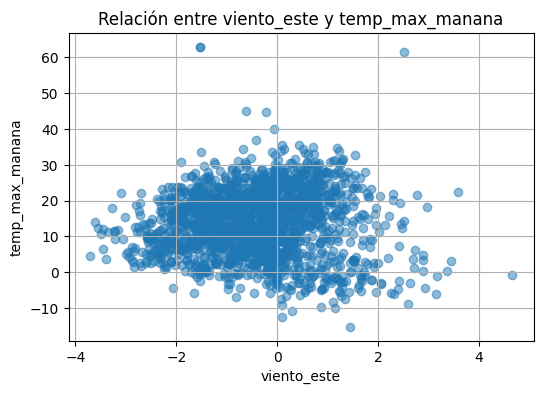

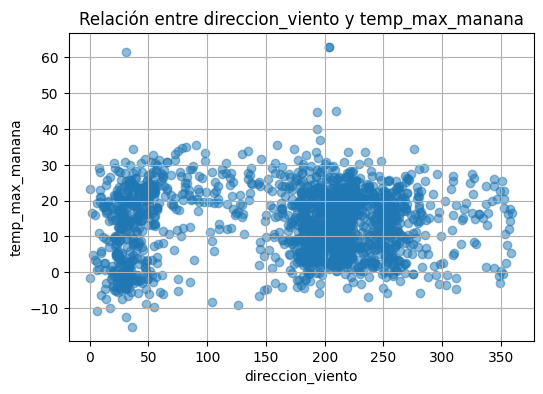

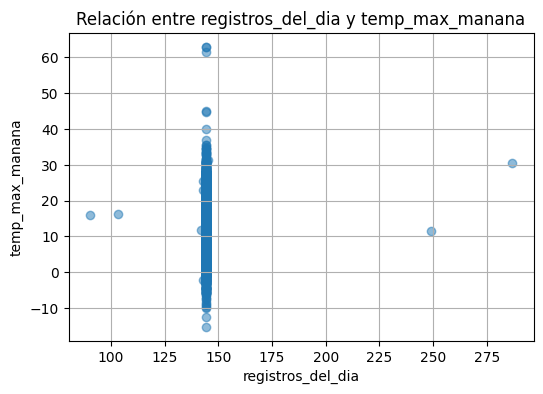

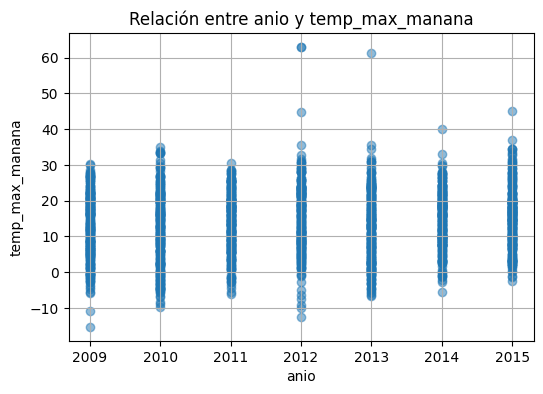

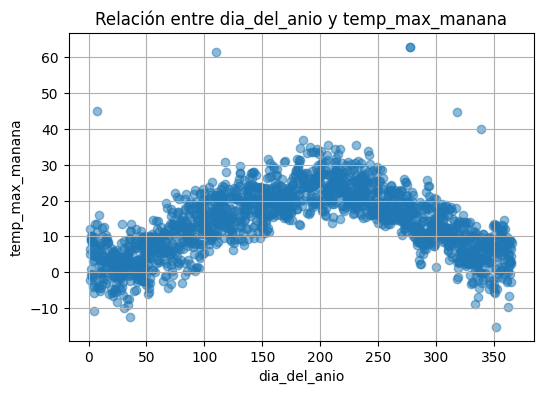

In [161]:
for variable in numeric_features_m1:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[variable], y_train, alpha=0.5)
    plt.title(f'Relación entre {variable} y {target}')
    plt.xlabel(variable)
    plt.ylabel(target)
    plt.grid()
    plt.show()

Es importante darse cuenta que estas graficas son con los datos originales por lo cual salen todavia los datos atipicos que se corrigen en el pipeline. 

Aparte de lo anterior, podemos ver que la mayoría de graficas parecen mostrar una relacion lineal entre las variables pero la última grafica de dia del anio parece mostrar una relacion no lineal, intentemos ofrecer una transformacion para entender esta variable de manera mas completa. Como es una relacion periodica, pues un año se repite de manera consistente podriamos pensar quizas en una transformacion periodica con funciones trigonométricas.

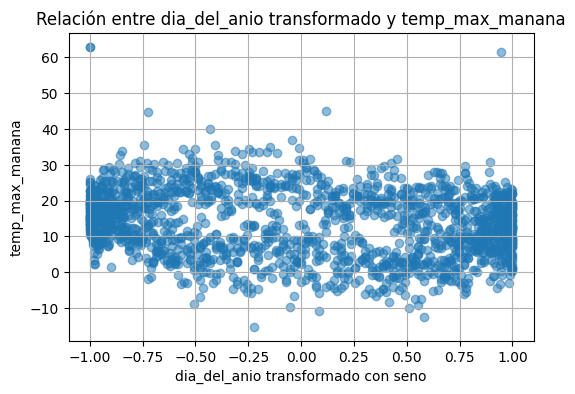

In [162]:
#grafica entre dia del año transformada con seno y temp_max_manana
plt.figure(figsize=(6, 4))
plt.scatter(np.sin(2 * np.pi * X_train["dia_del_anio"] / 365), y_train, alpha=0.5)
plt.title(f'Relación entre {"dia_del_anio"} transformado y {target}')
plt.xlabel("dia_del_anio transformado con seno")
plt.ylabel(target)
plt.grid()
plt.show()

Podemos ver que la grafica superior tiene una forma mucho mas consistente con una relacion lineal, por lo cual adoptar esta transformacion podria aumentar la validez de nuestro modelo. Incluyamos estra transformacion en nuestro pipeline.

In [163]:
#funcion para realizar transformacion de dia del año con seno 
def transformar_dia_anio_seno(df):
    df = df.copy()
    df["dia_del_anio_seno"] = np.sin(2 * np.pi * df["dia_del_anio"] / 365) #esta es la misma transformacion que se hizo en la grafica anterior
    return df

In [164]:
numeric_features_m3 = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio', 'dia_del_anio', 'dia_del_anio_seno', #se incluye dia_del_anio_seno
]

preprocessor_m3 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_m1, numeric_features_m3),#se hacen las mismas transformaciones que en m1 pero a las variables mas dia del año tranformado
    ('cat', categorical_transformer_m1, categorical_features_m1),
])

In [165]:
#hagamos el pipeline con la transformacion de dia del año con seno para modelo 3
pipeline_m3 = Pipeline(steps=[
    ('dropper', dropper),
    ('normalizar_categoricas', corrector_categoricas),
    ('corregir_rangos', corrector_rangos),
    ('transformar_dia_anio_seno', FunctionTransformer(transformar_dia_anio_seno)),
    ('preprocesamiento', preprocessor_m3),  # Usamos el mismo preprocesador que en el modelo 1
    ('modelo', LinearRegression()),
])

pipeline_m3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('normalizar_categoricas', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...t 0x1104f1580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, defaul

In [166]:
#hacemos el fit del modelo 3
pipeline_m3.fit(X_train, y_train)

y_train_pred_m3 = pipeline_m3.predict(X_train)
y_test_pred_m3 = pipeline_m3.predict(X_test)

rmse_train_m3 = np.sqrt(mean_squared_error(y_train, y_train_pred_m3))
mae_train_m3 = mean_absolute_error(y_train, y_train_pred_m3)
r2_train_m3 = r2_score(y_train, y_train_pred_m3)

rmse_test_m3 = np.sqrt(mean_squared_error(y_test, y_test_pred_m3))
mae_test_m3 = mean_absolute_error(y_test, y_test_pred_m3)
r2_test_m3 = r2_score(y_test, y_test_pred_m3)

print('Modelo 3 (variables reducidas, mediana, con transformacion de dia del año)')
print(f'  Train -> RMSE: {rmse_train_m3:.4f} | MAE: {mae_train_m3:.4f} | R2: {r2_train_m3:.4f}')
print(f'  Test  -> RMSE: {rmse_test_m3:.4f} | MAE: {mae_test_m3:.4f} | R2: {r2_test_m3:.4f}')

Modelo 3 (variables reducidas, mediana, con transformacion de dia del año)
  Train -> RMSE: 6.4504 | MAE: 4.9473 | R2: 0.5100
  Test  -> RMSE: 6.7027 | MAE: 5.2106 | R2: 0.4754


# 4. Tabla comparativa de rendimiento (test)

In [167]:
tabla_comparativa = pd.DataFrame({
    'Modelo': [
        'Modelo 1 - Todas las variables (media + escalado)',
        'Modelo 2 - Variables reducidas (mediana, sin escalado)',
        'Modelo 3 - Variables reducidas (mediana, con transformacion de dia del año)'
    ],
    'RMSE_test': [rmse_test_m1, rmse_test_m2, rmse_test_m3],
    'MAE_test': [mae_test_m1, mae_test_m2, mae_test_m3],
    'R2_test': [r2_test_m1, r2_test_m2, r2_test_m3],
}).set_index('Modelo')

tabla_comparativa = tabla_comparativa.sort_values('RMSE_test')
tabla_comparativa.round(4)

,RMSE_test,MAE_test,R2_test
Modelo,,,
"Modelo 3 - Variables reducidas (mediana, con transformacion de dia del año)",6.7027,5.2106,0.4754
Modelo 1 - Todas las variables (media + escalado),6.7805,5.2647,0.4631
"Modelo 2 - Variables reducidas (mediana, sin escalado)",8.0624,6.3832,0.2410


In [168]:
mejor_modelo = tabla_comparativa.index[0]
print(f'Mejor modelo segun RMSE en test: {mejor_modelo}')
print(tabla_comparativa.round(4))

Mejor modelo segun RMSE en test: Modelo 3 - Variables reducidas (mediana, con transformacion de dia del año)
                                                                             RMSE_test  \
Modelo                                                                                   
Modelo 3 - Variables reducidas (mediana, con transformacion de dia del año)     6.7027   
Modelo 1 - Todas las variables (media + escalado)                               6.7805   
Modelo 2 - Variables reducidas (mediana, sin escalado)                          8.0624   

                                                                             MAE_test  \
Modelo                                                                                  
Modelo 3 - Variables reducidas (mediana, con transformacion de dia del año)    5.2106   
Modelo 1 - Todas las variables (media + escalado)                              5.2647   
Modelo 2 - Variables reducidas (mediana, sin escalado)                         6.383